# Soccer Passing Networks

This Jupyter Notebook walks through the entire process of generating shot responsibilities, including data collection, processing, and fitting of the [HawkesTorch](https://github.com/ahmrr/HawkesTorch/tree/main) Hawkes Model for the 2015/2016 Barcelona Season. All data is publicly available from [StatsBomb](https://github.com/statsbomb/open-data.git) and this same proces can be used for any team and season.

In [1]:
import os
import sys
import warnings
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 1000
from statsbombpy import sb

warnings.filterwarnings("ignore", category = UserWarning, module = "statsbombpy")
sys.path.append(os.path.abspath(".."))

from src import dataCollection
from src import dataProcessing
from src import visualization
from src import modelFitting
from src import analysis
from src import matches


##### Collecting Data from StatsBomb

Specifying Team and Season for Data Collection

In [2]:
competitionId = 11
seasonId = 27
teamName = "Barcelona"

In [3]:
StatsbombMatches = dataCollection.APICall(competitionId, seasonId, teamName)

Processing Games: 100%|██████████| 38/38 [00:37<00:00,  1.03it/s]


##### Multi Game Data Collection

In [4]:
gameDfs, playerInformation = dataProcessing.multiGameCollection(StatsbombMatches, teamName)

In [5]:
gameDfs[0].head()

,Sender,Receiver,Timestamp,Type,xG,Location
0,1,8,0,Pass,0.0,"[60.0, 40.0]"
1,8,4,1,Pass,0.0,"[61.3, 41.0]"
2,4,7,5,Pass,0.0,"[50.6, 37.5]"
3,7,19,6,Pass,0.0,"[56.1, 31.3]"
4,19,6,9,Pass,0.0,"[43.6, 19.8]"


##### Passing Network Visualization

Pass Threshold is the minimum amount of passes a player needs to make to be displayed in the graph, which prevents low impact players from being graphed.

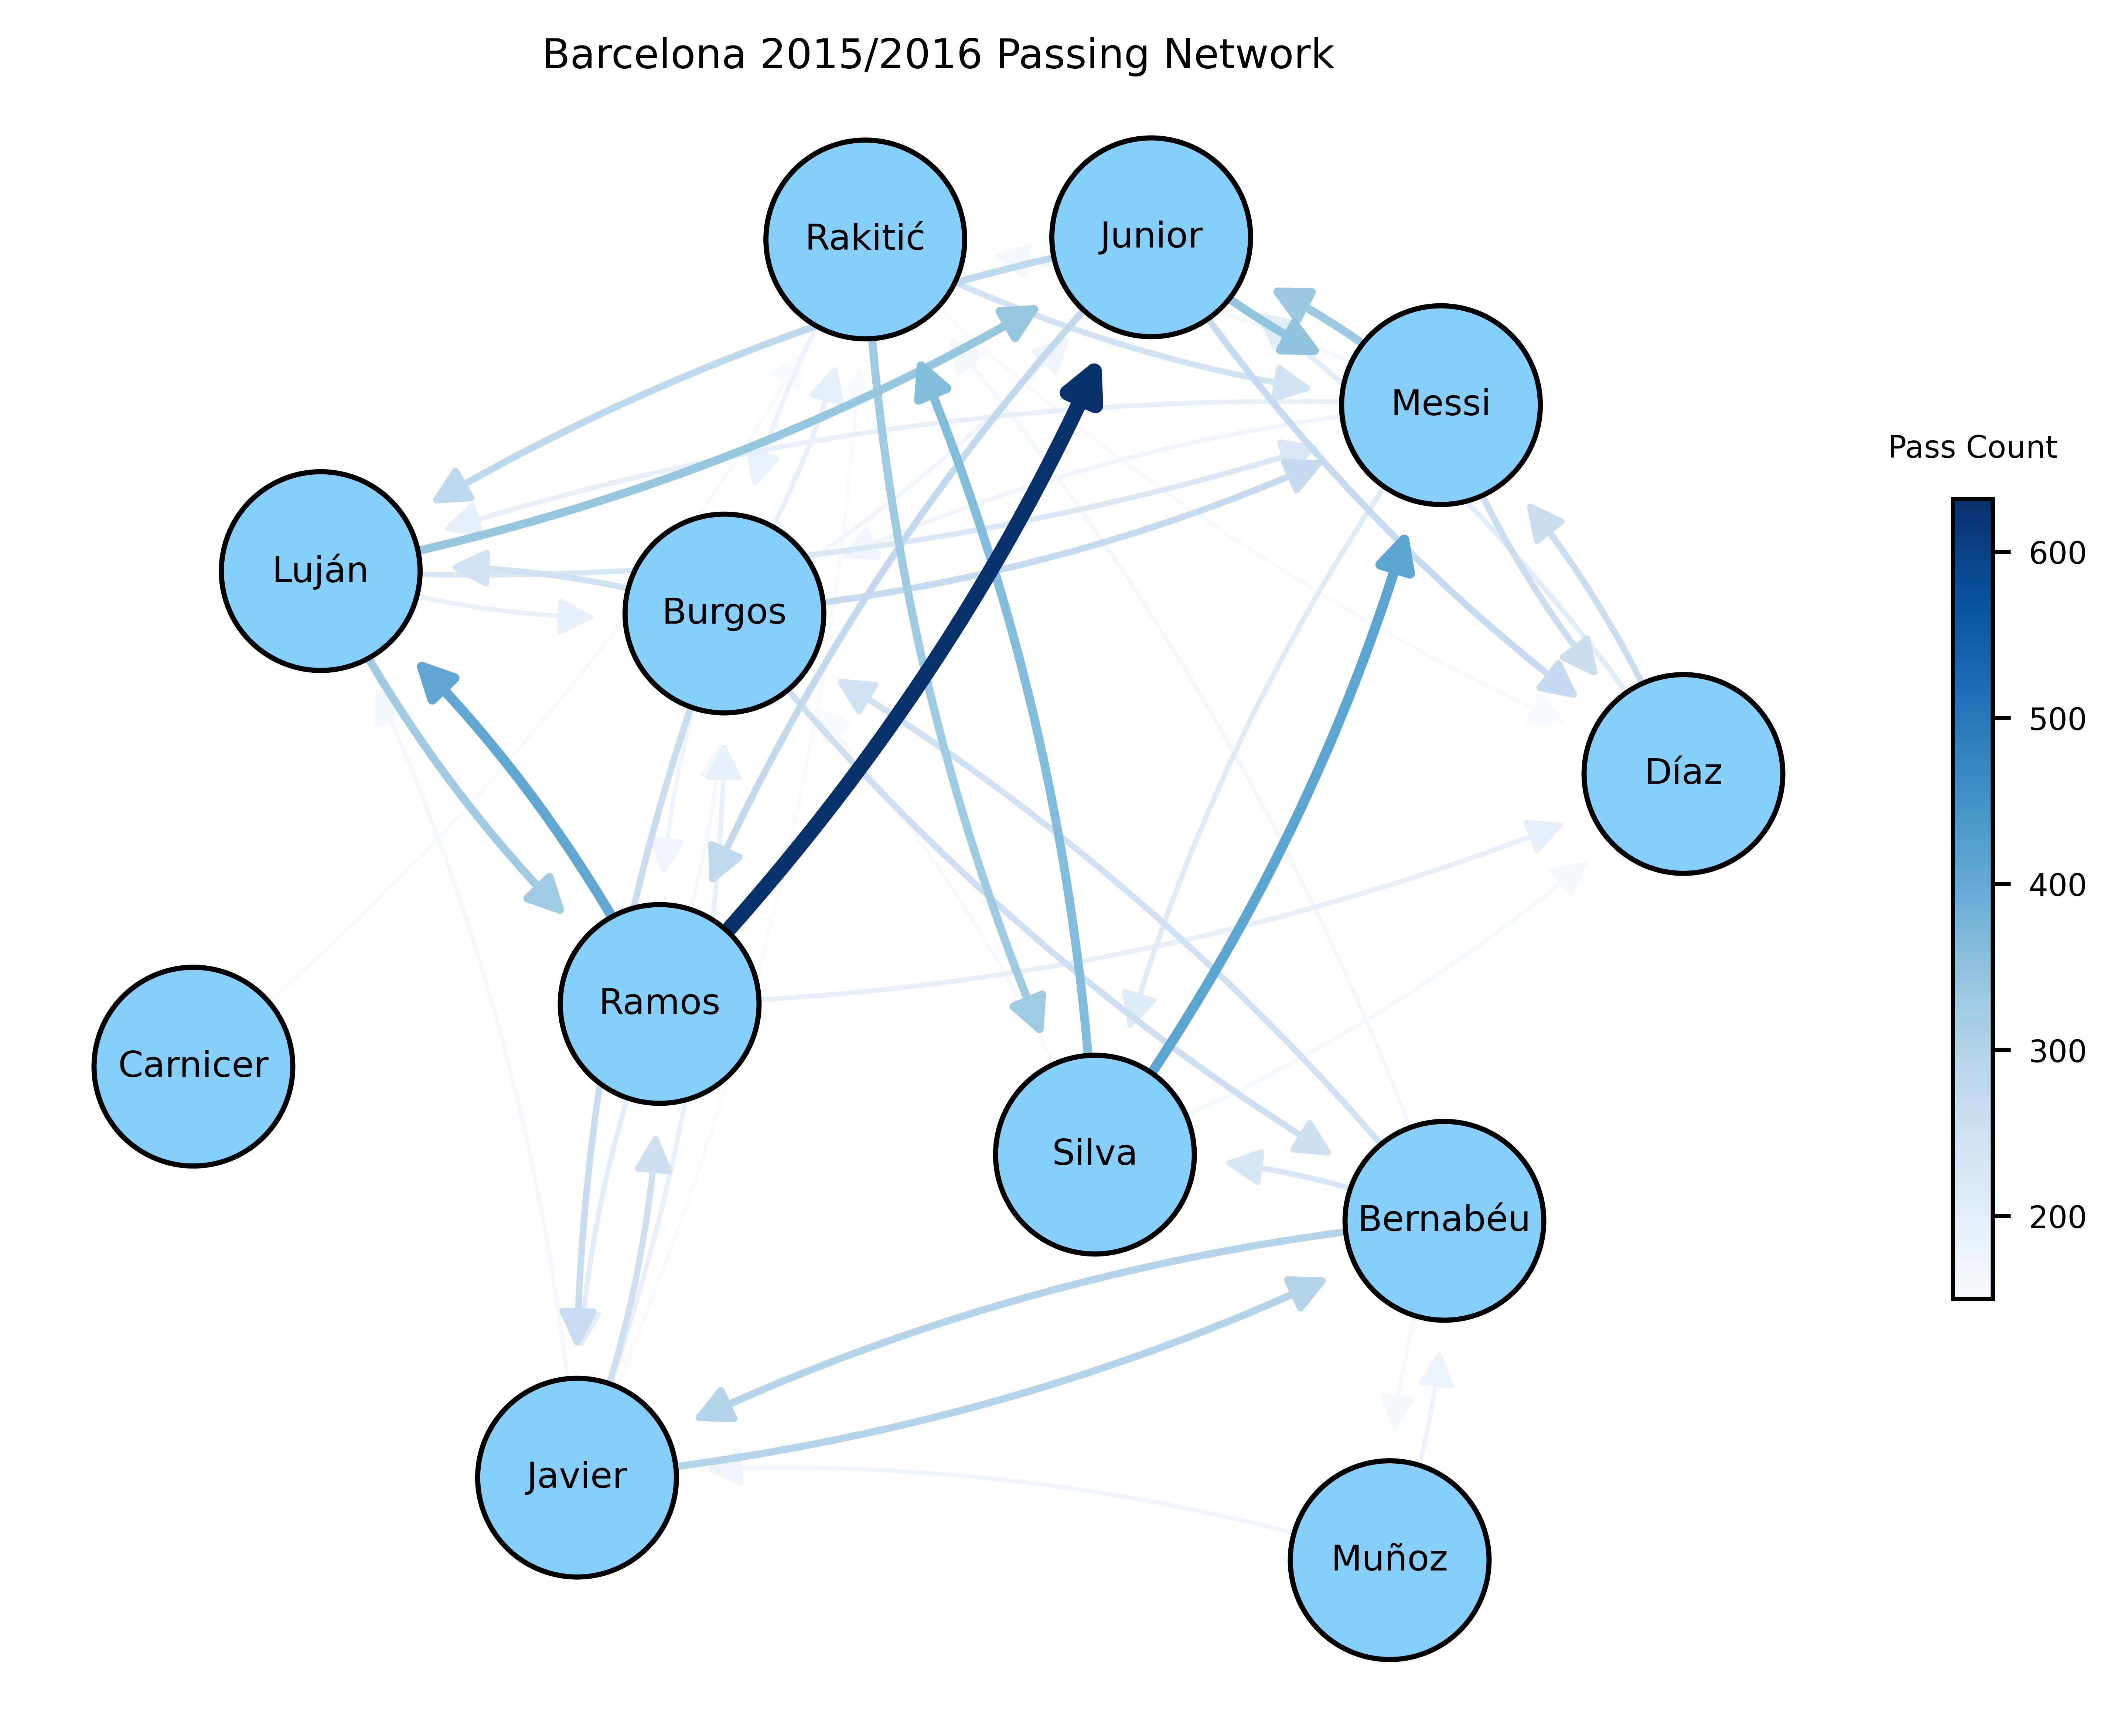

In [6]:
passThreshold = 150
margin = 25
k = 70

visualization.createPassingNetwork(teamName, gameDfs, passThreshold, playerInformation, margin, k)

##### Finding Minimum Pass Threshold
Due to the large amount of pairs that pass with one another over the course of a season, we will only select the most occuring ones to fit the alpha matrix on. This helps reduce dimensions of matrix and makes fitting much quicker. 

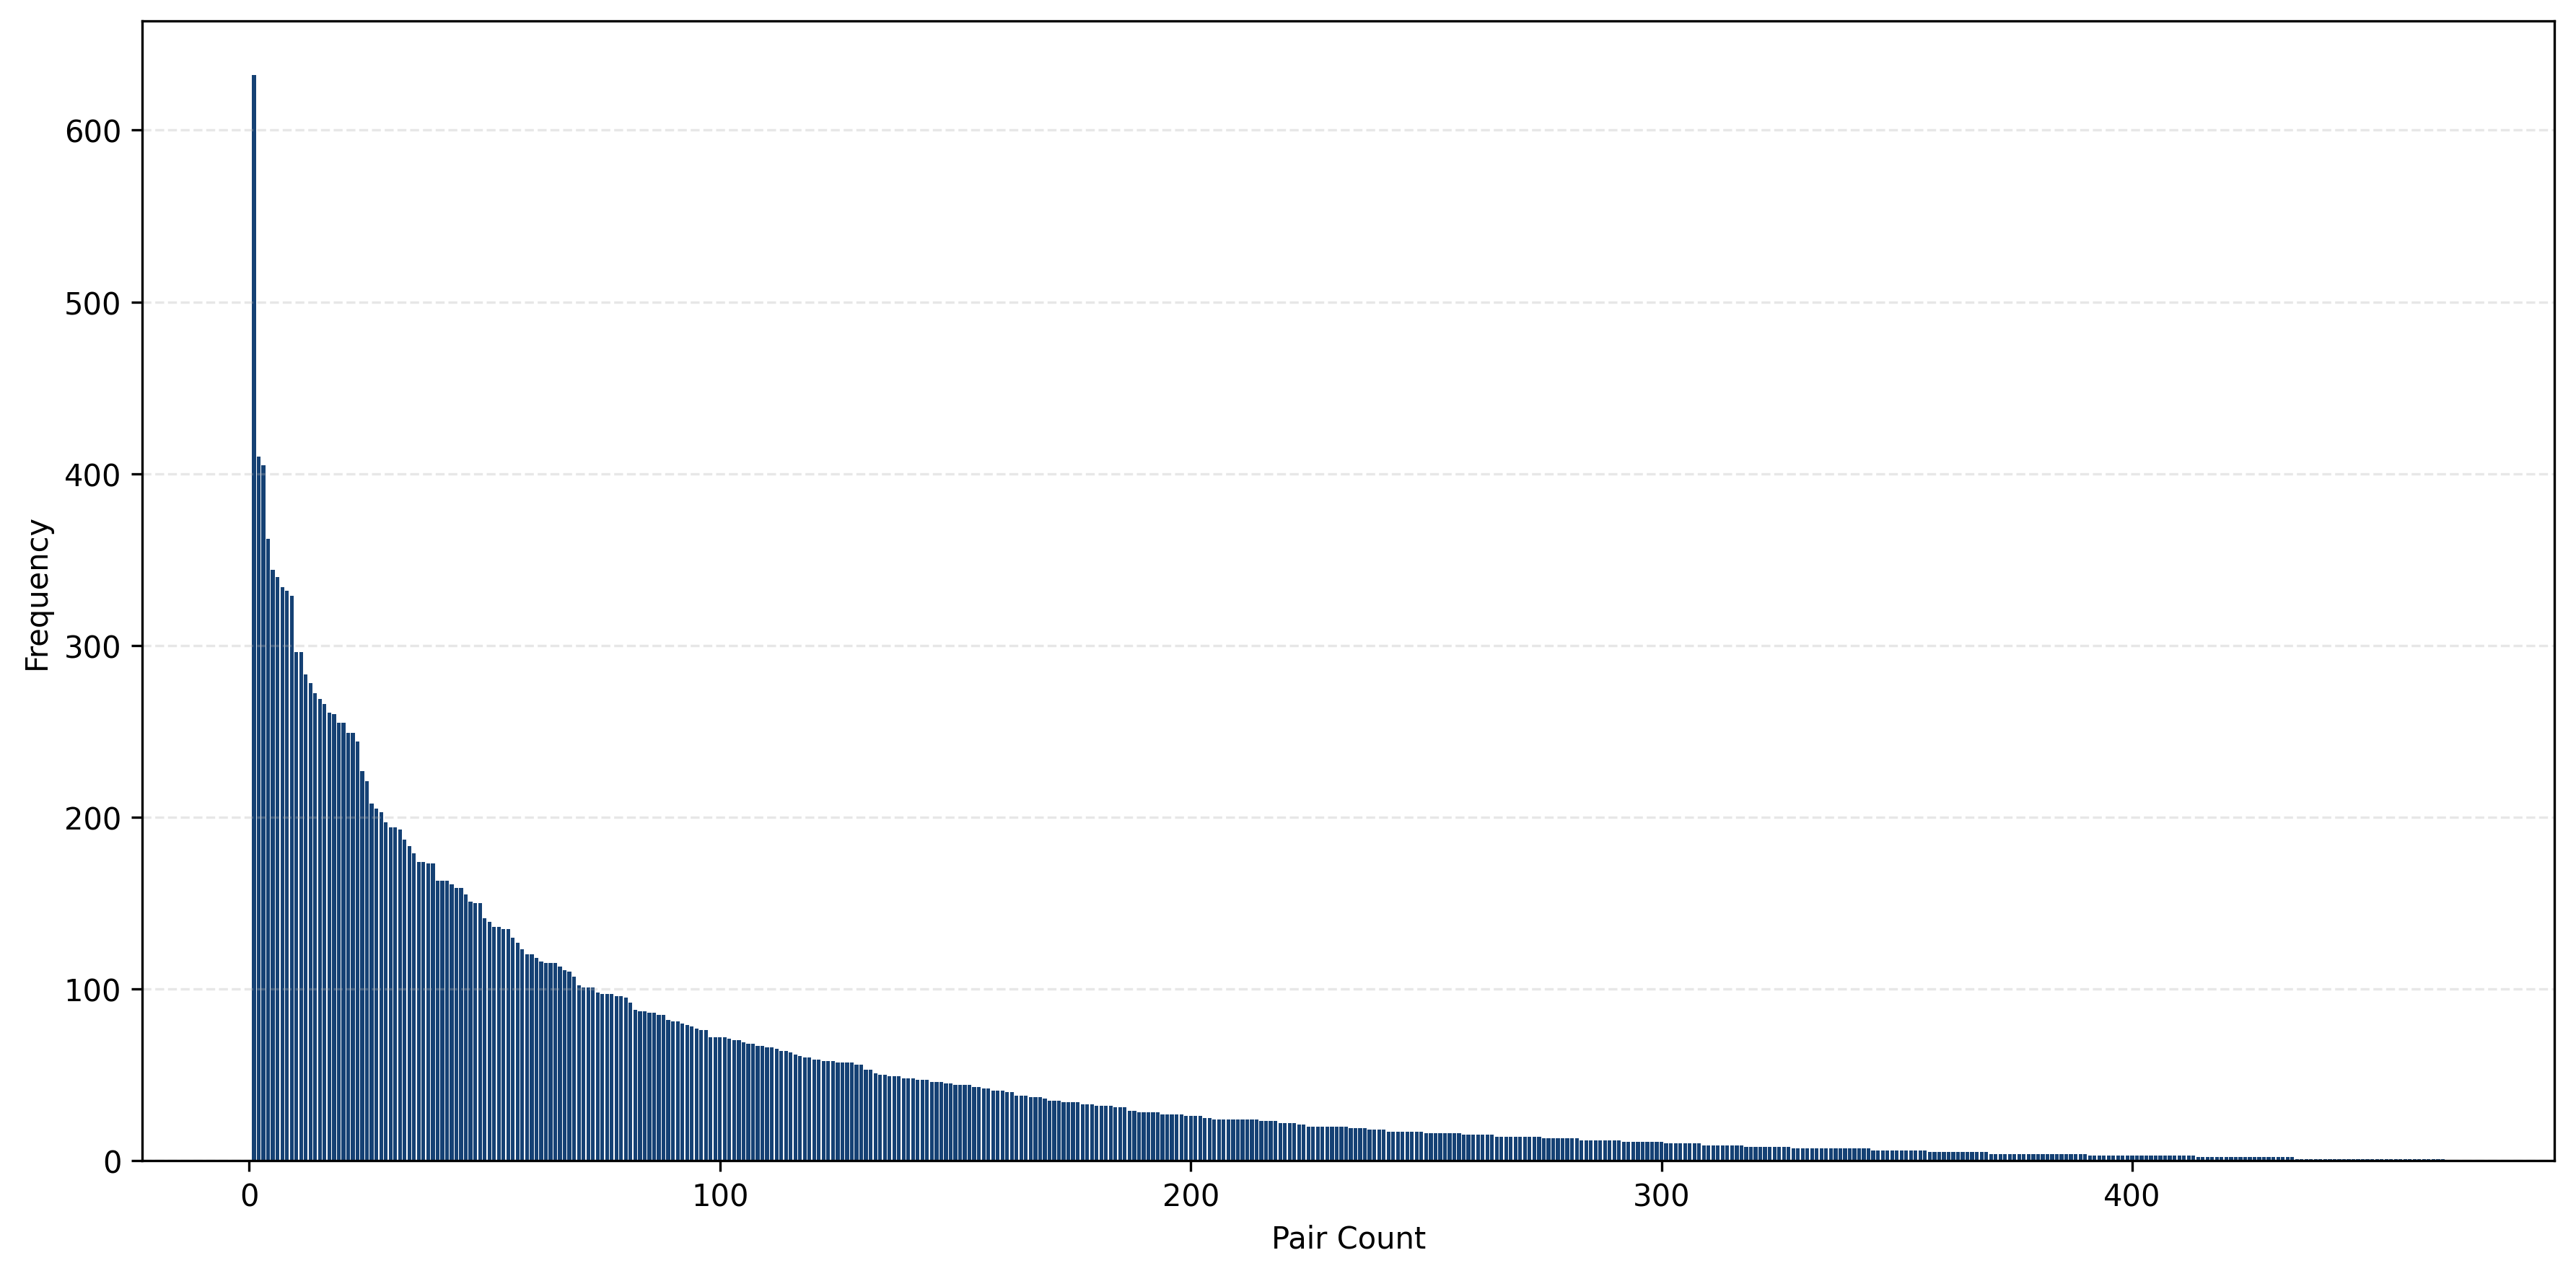

In [7]:
countPasses = dataProcessing.passCounts(gameDfs)
visualization.frequencyOfPairs(countPasses)

We can see that a dropoff occurs around 100 pairs.

##### Reformatting Data

In [8]:
pairs = 100

processedData, maxTimeStamp, pairData = dataProcessing.processData(gameDfs, pairs, playerInformation, teamName)

##### Model Fitting

In [9]:
beta = 0.2
maxIterations = 1000

mu, alpha, gamma, sequences = modelFitting.fitHawkesTorch(processedData, pairData, beta, maxIterations)

Total Event Types (M): 120


Optimizing Parameters: 100%|██████████| 1000/1000 [01:35<00:00, 10.49it/s, NLL/event=6.7290, events=17645]

Maximum Eigenvalue: 0.6393

Final Model Parameters:
Alpha Matrix Shape: (120, 120)
Alpha Matrix Sum: 72.1513
Average Baseline (Mu): 0.000266
Decay Rate (Beta): 0.20


##### Goal Alphas

The below matrix shows how much each passing pair influences a future shot on goal. 

In [18]:
goalAlphas, pairs = visualization.alphaGoalClustermap(alpha, teamName, playerInformation, pairData, 0.02)

##### Example Shot Responsibility for One Game

In [11]:
responsibilities, shotList = modelFitting.shotResponsibility(gameDfs, mu, beta, alpha, pairData, teamName, playerInformation)

In [12]:
responsibilities[0]

{65: {62: 0.355, 60: 0.16, 64: 0.143, 63: 0.096, 61: 0.038, 59: 0.016},
 78: {77: 0.954, 76: 0.007, 73: 0.007, 72: 0.003, 75: 0.002, 74: 0.002},
 148: {147: 0.448, 146: 0.159, 145: 0.095, 144: 0.054, 143: 0.022, 142: 0.016},
 186: {183: 0.268, 185: 0.218, 184: 0.187, 182: 0.085, 181: 0.0, 180: 0.0},
 208: {207: 0.923, 206: 0.027, 205: 0.013, 204: 0.009, 203: 0.003, 202: 0.001},
 210: {209: 0.828, 208: 0.009, 207: 0.006, 206: 0.002, 205: 0.001, 204: 0.001},
 212: {211: 0.842, 209: 0.002, 210: 0.0, 208: 0.0, 207: 0.0, 206: 0.0},
 218: {217: 0.34, 216: 0.159, 215: 0.125, 214: 0.0, 213: 0.0, 212: 0.0},
 250: {249: 0.859, 244: 0.031, 248: 0.025, 247: 0.016, 245: 0.007, 246: 0.007},
 367: {366: 0.402, 365: 0.233, 364: 0.083, 363: 0.036, 362: 0.036, 361: 0.026},
 368: {367: 0.353, 366: 0.289, 365: 0.136, 364: 0.064, 363: 0.026, 362: 0.022},
 392: {391: 0.978, 390: 0.0, 389: 0.0, 388: 0.0, 387: 0.0, 386: 0.0},
 450: {449: 0.438, 448: 0.262, 447: 0.027, 446: 0.012, 445: 0.01, 444: 0.007},
 472:

##### Shot Responsibility Interpretations

In [13]:
analysis.interpretShots(responsibilities[0], gameDfs[0], playerInformation)

[65: xG = 0.04] Shot at 6:36 by Luis Alberto Suárez Díaz (Center Forward Barcelona):
[62: 0.355] Pass at 6:30 by Daniel Alves da Silva (Right Back, Barcelona) to Sergi Roberto Carnicer (Right Back, Barcelona)
[60: 0.16] Pass at 6:26 by Daniel Alves da Silva (Right Back, Barcelona) to Sergi Roberto Carnicer (Right Back, Barcelona)
[64: 0.143] Pass at 6:35 by Munir El Haddadi Mohamed (Right Wing, Barcelona) to Luis Alberto Suárez Díaz (Center Forward, Barcelona)
[63: 0.096] Pass at 6:33 by Sergi Roberto Carnicer (Right Back, Barcelona) to Munir El Haddadi Mohamed (Right Wing, Barcelona)
[61: 0.038] Pass at 6:27 by Sergi Roberto Carnicer (Right Back, Barcelona) to Daniel Alves da Silva (Right Back, Barcelona)
[59: 0.016] Pass at 6:24 by Gerard Piqué Bernabéu (Right Center Back, Barcelona) to Daniel Alves da Silva (Right Back, Barcelona)

[78: xG = 0.05] Shot at 7:58 by Luis Alberto Suárez Díaz (Center Forward Barcelona):
[77: 0.954] Pass at 7:56 by Neymar da Silva Santos Junior (Left Wing

##### Season Long Statistics Generation

In [14]:
seasonStatistics, fullResponsibilities = matches.fullSeasonStatistics(StatsbombMatches, gameDfs, teamName, playerInformation, mu, beta, alpha, pairData)

In [15]:
seasonStatistics

,Name,Position,xGI,Games Played,Team Name,Average xGI
0,Adriano Correia Claro,Left Back,0.207,8,Barcelona,0.026
1,Aleix Vidal Parreu,Right Back,0.377,9,Barcelona,0.042
2,Andrés Iniesta Luján,Left Center Midfield,3.856,28,Barcelona,0.138
3,Arda Turan,Left Center Midfield,1.039,18,Barcelona,0.058
4,Claudio Andrés Bravo Muñoz,Goalkeeper,0.029,32,Barcelona,0.001
5,Daniel Alves da Silva,Right Back,2.591,29,Barcelona,0.089
6,Douglas Pereira dos Santos,Right Back,0.000,1,Barcelona,0.000
7,Gerard Gumbau Garriga,Left Defensive Midfield,0.000,3,Barcelona,0.000
8,Gerard Piqué Bernabéu,Right Center Back,0.514,30,Barcelona,0.017
9,Ivan Rakitić,Right Center Midfield,4.247,36,Barcelona,0.118


In [16]:
visualization.playerXGIHeatmap(gameDfs, fullResponsibilities, "Lionel Messi", 5503, teamName, playerInformation)

##### Pass Influence

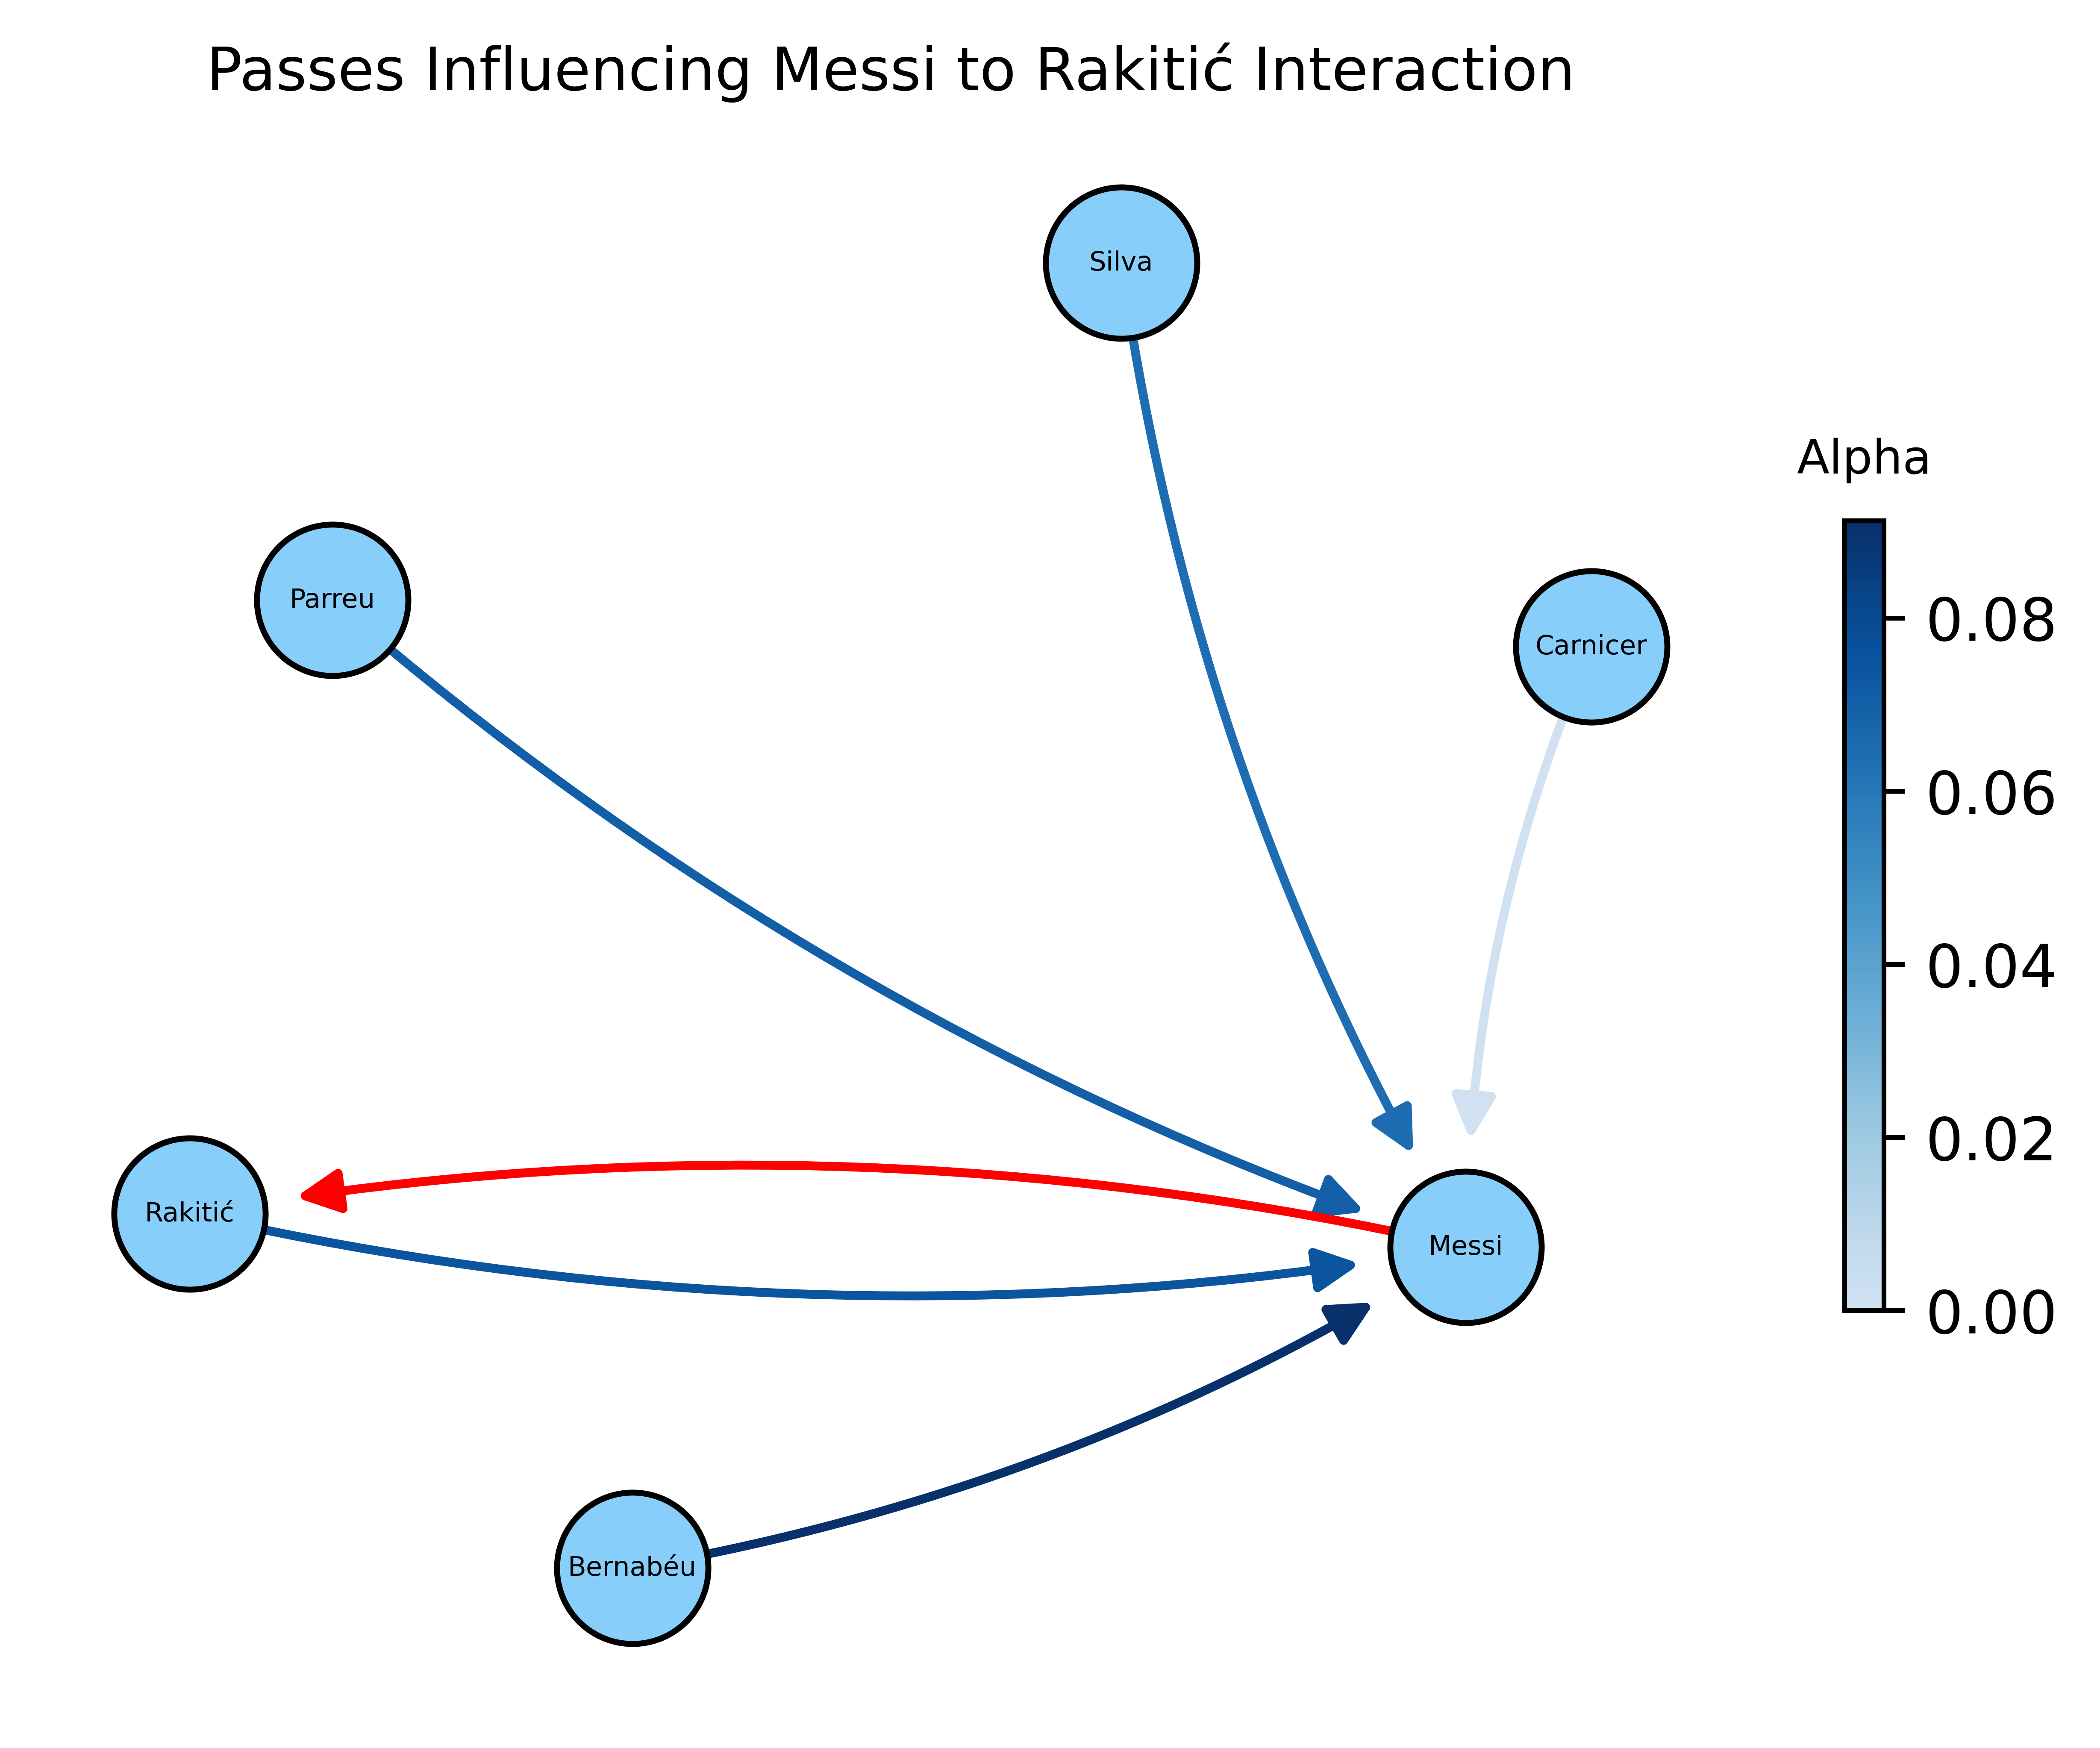

In [17]:
visualization.influenceGraph(playerInformation, alpha, (10, 9), True, pairs, "Barcelona", 0.04)